In [24]:
import tensorflow as tf
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

# Constants
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS_HEAD = 5       # Train classifier head first
EPOCHS_FINE = 5       # Fine-tune top backbone layers later

In [27]:
import zipfile
from pathlib import Path

# Paths
zip_path = "/kaggle/input/competitions/dogs-vs-cats-redux-kernels-edition/train.zip"
work_dir = Path("/kaggle/working/cats_dogs_raw")
work_dir.mkdir(exist_ok=True)

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(work_dir)

print("Dataset extracted successfully!")
print(f"Contents: {list(work_dir.iterdir())[:10]}")  # show first 10 files

Dataset extracted successfully!
Contents: [PosixPath('/kaggle/working/cats_dogs_raw/train')]


In [28]:
import shutil

cats_dir = Path("/kaggle/working/cats_dogs/cats")
dogs_dir = Path("/kaggle/working/cats_dogs/dogs")
cats_dir.mkdir(parents=True, exist_ok=True)
dogs_dir.mkdir(parents=True, exist_ok=True)

# Move images to class folders
for file in work_dir.iterdir():
    if file.name.startswith("cat"):
        shutil.copy(file, cats_dir / file.name)
    elif file.name.startswith("dog"):
        shutil.copy(file, dogs_dir / file.name)

print("Dataset organized into 'cats' and 'dogs' folders.")

Dataset organized into 'cats' and 'dogs' folders.


In [29]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/cats_dogs",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(160, 160),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/cats_dogs",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(160, 160),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [30]:
# Step 3: Build MobileNetV2 model (offline weights)
import tensorflow as tf

IMG_SIZE = (160, 160)

def build_model():
    # Offline weights path (add your input in Kaggle first)
    weights_path = "/kaggle/input/datasets/me221522/mobilnet/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_160_no_top.h5"
    
    # Load MobileNetV2 backbone
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights=weights_path  # offline weights
    )
    
    # Freeze backbone initially
    base_model.trainable = False
    
    # Build classifier head
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    
    # Complete model
    model = tf.keras.Model(inputs, outputs)
    
    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model, base_model

# Build the model
model, base_model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 252s 397ms/step - accuracy: 0.9650 - loss: 0.0874 - val_accuracy: 0.9798 - val_loss: 0.0465
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 318ms/step - accuracy: 0.9849 - loss: 0.0410 - val_accuracy: 0.9842 - val_loss: 0.0387
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.9906 - loss: 0.0275 - val_accuracy: 0.9816 - val_loss: 0.0429
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 314ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.9842 - val_loss: 0.0414
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 325ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9836 - val_loss: 0.0508
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 318s 492ms/step - accuracy: 0.9370 - loss: 0.2154 - val_accuracy: 0.9820 - val_loss: 0.0509
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 491ms/step - accuracy

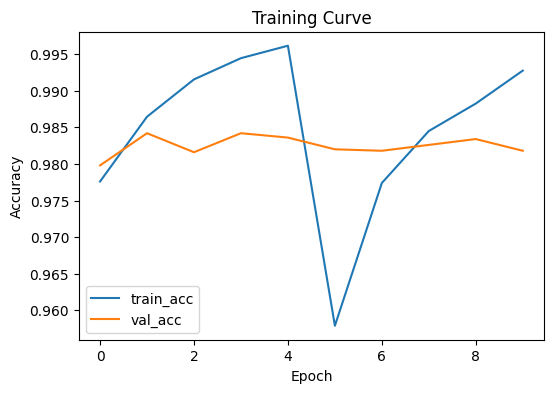

Model saved as 'cat_dog_transfer.h5'


In [31]:
# Step 4: Train the model and plot training curve
import matplotlib.pyplot as plt

EPOCHS_HEAD = 5   # Train classifier head first
EPOCHS_FINE = 5   # Fine-tune top backbone layers later
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

# Dataset paths
data_dir = "/kaggle/working/cats_dogs"

# Load training and validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Step 4a: Train head first
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD
)

# Step 4b: Fine-tuning - unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Compile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

# Combine histories
for k in history_fine.history:
    history_head.history[k].extend(history_fine.history[k])

# Plot training curve
plt.figure(figsize=(6,4))
plt.plot(history_head.history['accuracy'], label='train_acc')
plt.plot(history_head.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Curve')
plt.show()



In [33]:
# Save model in native Keras format
model.save("/kaggle/working/cat_dog_transfer.keras")
print("Model saved as 'cat_dog_transfer.keras'")

Model saved as 'cat_dog_transfer.keras'


In [37]:
# Copy a test image from training folders
from pathlib import Path
import shutil

test_img_path = Path("/kaggle/working/test_image.jpg")
shutil.copy("/kaggle/working/cats_dogs/cats/cat.0.jpg", test_img_path)

PosixPath('/kaggle/working/test_image.jpg')

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step


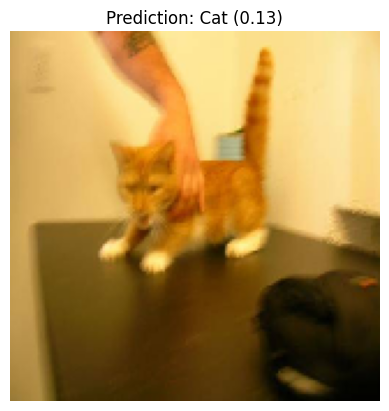

In [40]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil

# Step 1: Load the model in native Keras format
model = tf.keras.models.load_model("/kaggle/working/cat_dog_transfer.keras")
print("Model loaded successfully!")

# Step 2: Copy a test image from training folders
test_img_path = Path("/kaggle/working/test_image.jpg")
shutil.copy("/kaggle/working/cats_dogs/cats/cat.0.jpg", test_img_path)

# Step 3: Load and preprocess the test image
img = image.load_img(test_img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Step 4: Predict
pred = model.predict(img_array)
label = "Dog" if pred[0][0] > 0.5 else "Cat"

# Step 5: Show result
plt.imshow(img)
plt.title(f"Prediction: {label} ({pred[0][0]:.2f})")
plt.axis("off")
plt.show()

In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing import image

# Step 1: Create test dataset (simulate using some train images)
test_dir = Path("/kaggle/working/test_images")
test_dir.mkdir(exist_ok=True)

# Copy first 10 cats and dogs as test images
for i in range(5):
    shutil.copy(f"/kaggle/working/cats_dogs/cats/cat.{i}.jpg", test_dir / f"cat.{i}.jpg")
    shutil.copy(f"/kaggle/working/cats_dogs/dogs/dog.{i}.jpg", test_dir / f"dog.{i}.jpg")

# Step 2: Predict all test images
results = []
for img_path in test_dir.iterdir():
    img = image.load_img(img_path, target_size=(160, 160))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    pred = model.predict(img_array)
    label = "dog" if pred[0][0] > 0.5 else "cat"
    results.append({"filename": img_path.name, "prediction": label, "prob": float(pred[0][0])})

# Step 3: Convert to DataFrame and show
df = pd.DataFrame(results)
print(df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
    filename prediction      prob
0  dog.0.jpg        cat  0.167730
1  dog.4.jpg        cat  0.137059
2  dog.3.jpg        cat  0.128888
3  cat.2.jpg        cat  0.184814
4  cat.1.jpg        cat  0.135482
5  cat.0.jpg        cat  0.127696
6  dog.1.jpg        cat  0.125237
7  cat.3.jpg        cat  0.141534
8  dog.2.jpg        cat  0.130964
9  cat.4.jpg        cat  0.116281


In [42]:
df.to_csv("/kaggle/working/dog_cat_predictions.csv", index=False)
print("Predictions saved as 'dog_cat_predictions.csv'")

Predictions saved as 'dog_cat_predictions.csv'
